### Q2. Unsupervised Learning
1. Data Preparation

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB
None
             age   annual_spend  visits_per_month  basket_size  \
count  500.00000     500.000000        500.000000   500.000000   
mean    40.45200   48856.948000          8.414000  2682.286000   
std     14.42664   32856.795353          5.324595  2274.957339   
min     18.00000    5038.000000          1.000000   212.000000   
25%     28.00000   19213.250000          4.000000   727.750000   
50%     41.00000   44257.000000          8.

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


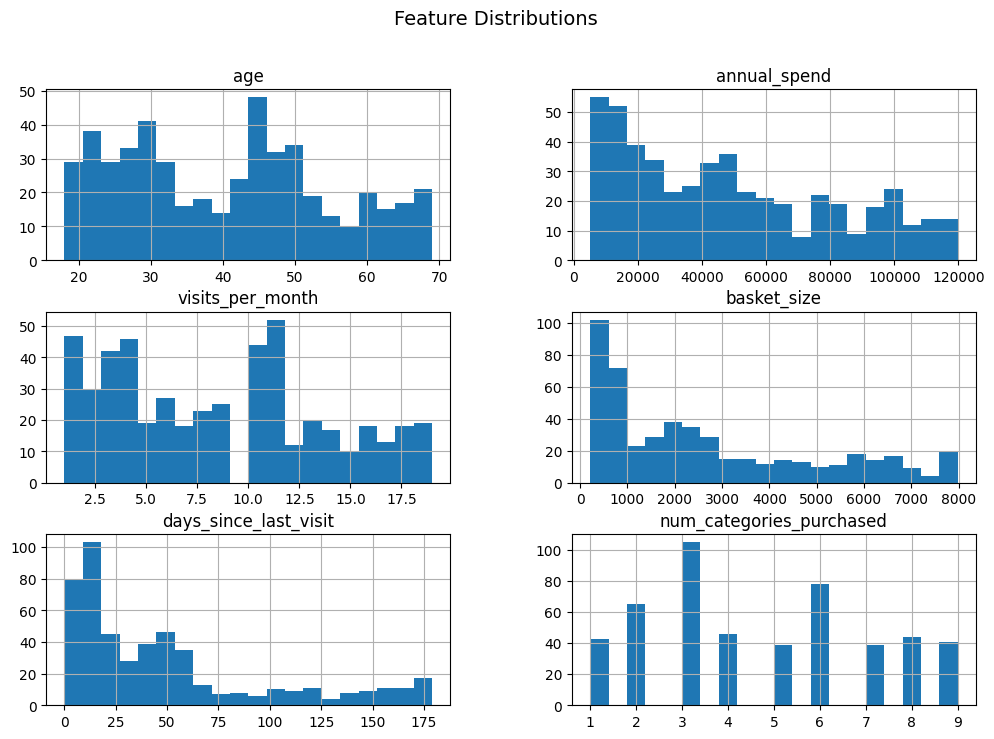

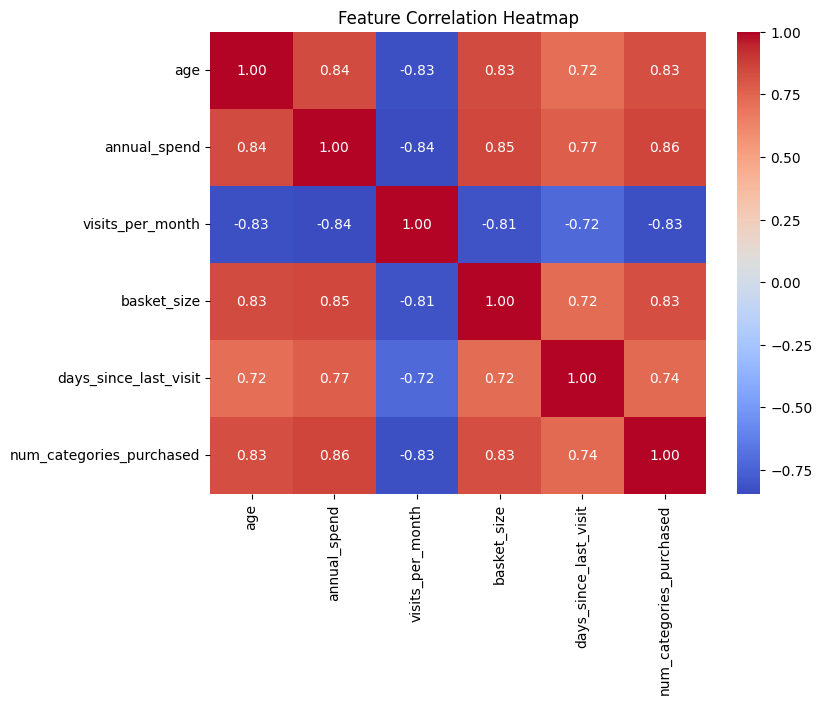

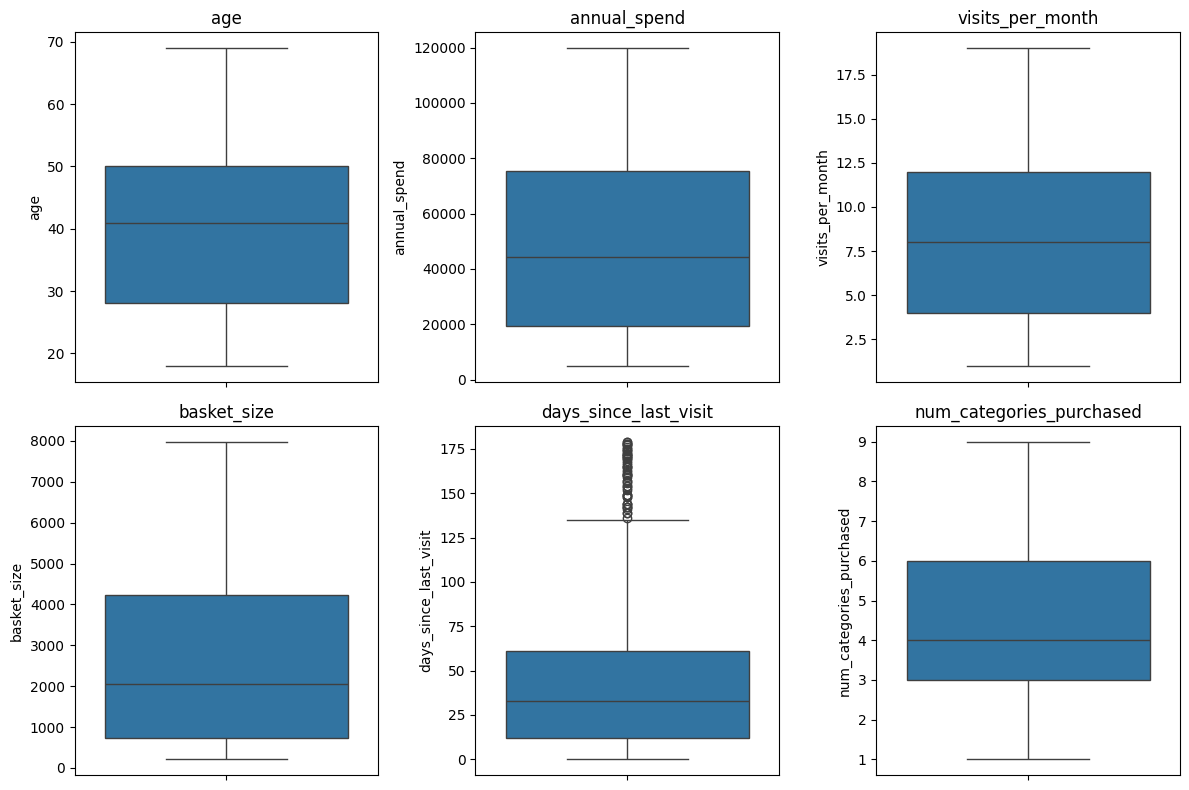

✅ Successfully scaled the data. Here are the first 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


In [7]:
# Task 1: Data Preparation. I am doing EDA and preprocessing for clustering analysis. 
# I will load the dataset, select relevant features, and apply scaling
#  to ensure that all features contribute equally to the clustering process. 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- Load dataset ---
df = pd.read_csv("../data/q2_customers.csv")

# Features to use
features = ["age", "annual_spend", "visits_per_month", 
            "basket_size", "days_since_last_visit", 
            "num_categories_purchased"]

X = df[features]

# --- Exploratory Data Analysis (EDA) ---

# Basic info and summary
print(df.info())
print(df.describe())
display(df.head())

# Histograms for distributions
df[features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Boxplots to check for outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# --- Preprocessing: Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for clarity
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Confirmation print + preview
print("✅ Successfully scaled the data. Here are the first 5 rows:")
X_scaled_df.head()


### Why Scaling is Essential Before K-Means

K-Means uses **Euclidean distance** to form clusters. If features are on different scales (e.g., `annual_spend` in thousands vs. `visits_per_month` in tens), larger values dominate the distance calculation.  

Scaling with **StandardScaler** ensures all features have mean = 0 and variance = 1, so each contributes equally and clusters reflect true customer patterns rather than unit differences.


2. Choosing K — Elbow Method

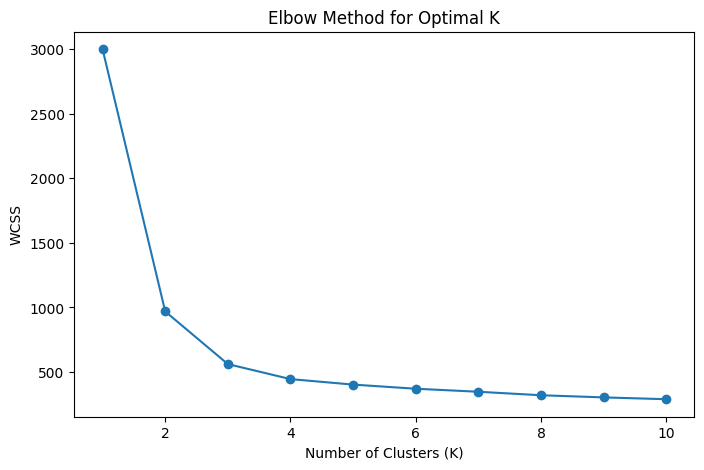

In [8]:
# Task 2: Choosing K — Elbow Method

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []  # Within-Cluster Sum of Squares

# Compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


### Optimal K from Elbow Method

The **Elbow Method** shows how WCSS decreases as K increases.  
At first, WCSS drops sharply, but after a certain point the improvement slows.  
This "elbow point" indicates the optimal K, where adding more clusters gives diminishing returns.  

From the plot, the elbow appears around **K = 4 or 5**, suggesting that 4–5 clusters best balance compactness and simplicity for customer segmentation.


3. K-Means Clustering 

In [9]:
# Task 3: K-Means Clustering

from sklearn.cluster import KMeans

# Fit KMeans with chosen K (I have selected  K=4 from elbow method) The elbow curve already showed a clear bend here.
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Add cluster labels to the original dataframe
df["cluster"] = kmeans.fit_predict(X_scaled)

# Cluster centroids (scaled space)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)

# Set index name so clusters show clearly in the header
centroids.index.name = "cluster"

# Display centroids with cluster IDs aligned properly
centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.150795,1.247783,-1.118857,1.150217,1.984595,1.161639
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968
3,1.114725,1.224083,-1.095219,1.350241,0.317376,1.183676


### Cluster Interpretation

- **Cluster 0**: Younger, frequent visitors with low spend and small baskets → **budget-conscious, high-frequency shoppers**.  
- **Cluster 1**: Middle-aged, moderate visits and spending → **steady, mid-value customers**.  
- **Cluster 2**: Older, high annual spend and large baskets but fewer visits → **premium, high-value customers**.  
- **Cluster 3**: Mixed-age, moderate spend and basket sizes, occasional visits → **average-value, occasional shoppers**.


4. Dimensionality Reduction with PCA

In [10]:
# Task 4: Dimensionality Reduction with PCA

from sklearn.decomposition import PCA

# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
print(f"Explained variance ratio: PC1 = {explained_var[0]:.4f}, PC2 = {explained_var[1]:.4f}")

# Feature loadings (components)
loadings = pd.DataFrame(pca.components_, columns=features, index=["PC1", "PC2"])
print("\nFeature loadings (components):")
loadings


Explained variance ratio: PC1 = 0.8356, PC2 = 0.0557

Feature loadings (components):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

- **PC1**: Captures overall spending behavior — strong positive loadings on `annual_spend`, `basket_size`, and `num_categories_purchased`. This axis separates **high-value customers** from **budget-conscious shoppers**.  
- **PC2**: Captures visit frequency and recency — loadings on `visits_per_month` and `days_since_last_visit`. This axis distinguishes **frequent, engaged customers** from **infrequent or lapsed customers**.  

Together, PC1 and PC2 provide a 2D view where clusters can be visualized as combinations of **value** (spend/basket size) and **engagement** (visit frequency/recency).


5. Cluster Visualisation 

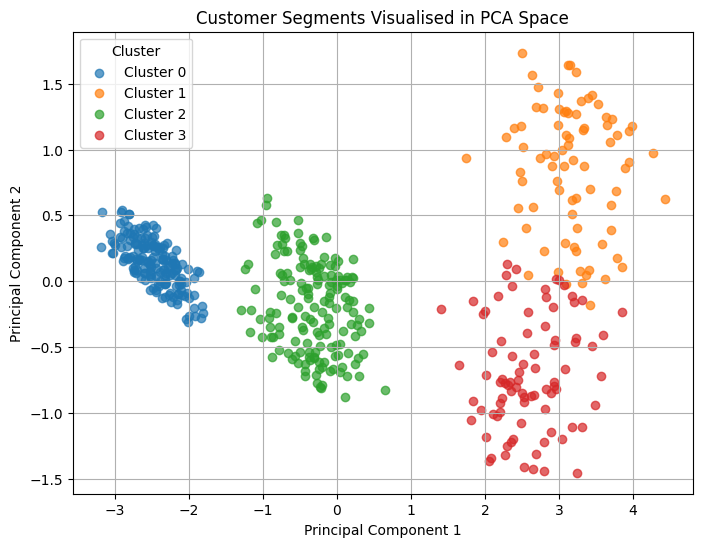

In [11]:
# Task 5: Cluster Visualisation

# Add cluster labels to PCA-transformed data
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"]

# Scatter plot of PC1 vs PC2
plt.figure(figsize=(8, 6))
for cluster_id in sorted(pca_df["cluster"].unique()):
    cluster_points = pca_df[pca_df["cluster"] == cluster_id]
    plt.scatter(cluster_points["PC1"], cluster_points["PC2"], label=f"Cluster {cluster_id}", alpha=0.7)

plt.title("Customer Segments Visualised in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


## Final Conclusion — Customer Segmentation

Using K‑Means clustering with K = 4, we identified distinct customer segments:

- **Cluster 0:** Younger, frequent visitors with low spend and small baskets → budget‑conscious, high‑frequency shoppers.  
- **Cluster 1:** Middle‑aged, moderate visits and spending → steady, mid‑value customers.  
- **Cluster 2:** Older, high annual spend and large baskets but fewer visits → premium, high‑value customers.  
- **Cluster 3:** Mixed‑age, moderate spend and basket sizes, occasional visits → average‑value, occasional shoppers.

PCA confirmed that **PC1 captures spending power and basket size**, while **PC2 captures visit frequency and recency**. The 2D visualization shows clear separation between high‑value customers and low‑spend frequent visitors.

**Business interpretation:**  
These clusters provide actionable insights for marketing and retention:  
- Target **Cluster 0** with promotions to increase basket size.  
- Retain **Cluster 2** with loyalty rewards and personalized offers.  
- Upsell **Cluster 3** with cross‑category bundles.  
- Nurture **Cluster 1** with engagement campaigns to boost spend.
